# Daily Animal Review

Everyday animal-level review notebook. It combines the across-session checks and the overall RT/MT/psychometric/JND plots for one animal.

To run the entire cohort:
./.conda/bin/python scripts/run_daily_animal_review_notebook_batch.py \
  --line CNTNAP2 \
  --cohort cohort4 \
  --animals ASD0062 \
  --kernel python3

To run a specific group within the cohort:
./.conda/bin/python scripts/run_daily_animal_review_notebook_batch.py \
  --line CNTNAP2 \
  --cohort cohort4 \
  --kernel python3 \
  --animals $(printf "ASD%04d " {63..70}) \

Add for level control:
  --training-level-max 16







to add:
daily plot - one session in revision

## 1. Setup

In [1]:
from pathlib import Path
import os
import sys

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "analysis" / "daily_merge.py").exists() and (candidate / "DataFiles").exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Could not find the Mafalda_analysis repo root from the current working directory."
    )

os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

%load_ext autoreload
%autoreload 2

ROOT

PosixPath('/Users/mafaldavalente/Documents/Mafalda_analysis')

## 2. Choose Animal

In [5]:
LINE = "SHANK3"
COHORT = "cohort1"
SUBJECT_FILE = "merged_ASD0023.csv"
TRAINING_LEVEL = 16
TRAINING_LEVEL_MAX = None
LOAD_REFERENCE = True
SAVE_FIGURES = False
OUTPUT_DIR = None
FIGURE_DPI = 250

## 3. Load Once, Prepare Both Views

In [6]:
from Pipeline.daily_plots import (
    load_daily_animal_data,
    load_reference_data,
    prepare_daily_animal_data,
)
from Pipeline.across_sessions import (
    load_change_regions,
    prepare_across_sessions_data,
    subject_id_from_file,
)
import Pipeline.biased_blocks as bb
import pandas as pd


def filter_daily_review_rows(df):
    out = df.copy()
    session_type = pd.to_numeric(out.get("session_type"), errors="coerce")
    short_duration = pd.to_numeric(out.get("short_duration"), errors="coerce")

    keep_non_23 = ~session_type.eq(23)
    keep_23 = pd.Series(False, index=out.index, dtype=bool)
    type23 = out[session_type.eq(23)].copy()
    if not type23.empty:
        labeled_23 = bb.add_biased_block_condition(
            type23,
            biased_session_types=(23,),
            unbiased_rt_session_types=(),
            short_duration_value=None,
        )
        keep_23 = out.index.isin(labeled_23.index[labeled_23["block_condition"].eq("unbiased")])
    keep_23_like_rt_unbiased = keep_23 & short_duration.eq(0)
    return out[keep_non_23 | keep_23_like_rt_unbiased].copy()


df_raw, data_dir = load_daily_animal_data(
    subject_file=SUBJECT_FILE,
    line=LINE,
    cohort=COHORT,
)
df_daily_input = filter_daily_review_rows(df_raw)

subject_id = subject_id_from_file(SUBJECT_FILE)
across_prepared = prepare_across_sessions_data(df_raw, training_level=TRAINING_LEVEL, training_level_max=TRAINING_LEVEL_MAX)
daily_prepared = prepare_daily_animal_data(df_daily_input, training_level=TRAINING_LEVEL, training_level_max=TRAINING_LEVEL_MAX)
regions = load_change_regions(data_dir=data_dir, subject_id=subject_id)
reference = load_reference_data() if LOAD_REFERENCE else None

print(f"Subject: {subject_id}")
print(f"Data directory: {data_dir}")
print(f"Raw rows: {len(df_raw)}")
print(f"Daily-input rows after session-23 unbiased-block RT filter: {len(df_daily_input)}")
print(f"Across-session rows: {len(across_prepared['df'])}")
print(f"Daily-plot rows: {len(daily_prepared['df'])}")
daily_prepared["info"]

/Users/mafaldavalente/Documents/Mafalda_analysis/Pipeline/daily_plots.py:109: DtypeWarning: Columns (0: reward_delivered, 1: opto_mode, 2: opto_onset) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path), data_dir


    ABL       JND
0  20.0  2.971257
1  40.0  3.486012
2  59.0  2.489489
3  60.0  3.179088
Subject: ASD0023
Data directory: /Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/SHANK3_cohort1
Raw rows: 53724
Daily-input rows after session-23 unbiased-block RT filter: 40735
Across-session rows: 42142
Daily-plot rows: 29276


{'animal': 'ASD0023',
 'setup': array([5, 4, 9, 6]),
 'session_type': array([ 1,  2, 23]),
 'n_sessions': 96,
 'sessions_by_type': {'1': [np.int64(18),
   np.int64(20),
   np.int64(21),
   np.int64(22),
   np.int64(23),
   np.int64(24),
   np.int64(25),
   np.int64(26)],
  '2': [np.int64(27),
   np.int64(28),
   np.int64(29),
   np.int64(30),
   np.int64(31),
   np.int64(32),
   np.int64(33),
   np.int64(34),
   np.int64(35),
   np.int64(36),
   np.int64(37),
   np.int64(38),
   np.int64(39),
   np.int64(40),
   np.int64(41),
   np.int64(42),
   np.int64(43),
   np.int64(44),
   np.int64(45),
   np.int64(46),
   np.int64(47),
   np.int64(48),
   np.int64(49),
   np.int64(50),
   np.int64(51),
   np.int64(52),
   np.int64(53),
   np.int64(54),
   np.int64(55),
   np.int64(56),
   np.int64(57),
   np.int64(58),
   np.int64(59),
   np.int64(60),
   np.int64(61),
   np.int64(62),
   np.int64(63),
   np.int64(64),
   np.int64(65),
   np.int64(66),
   np.int64(67),
   np.int64(68),
   np.int

## 4. Figure 1: Across-Session Review

Large slide-friendly figure with trial counts on the left and behavioral metrics on the right.

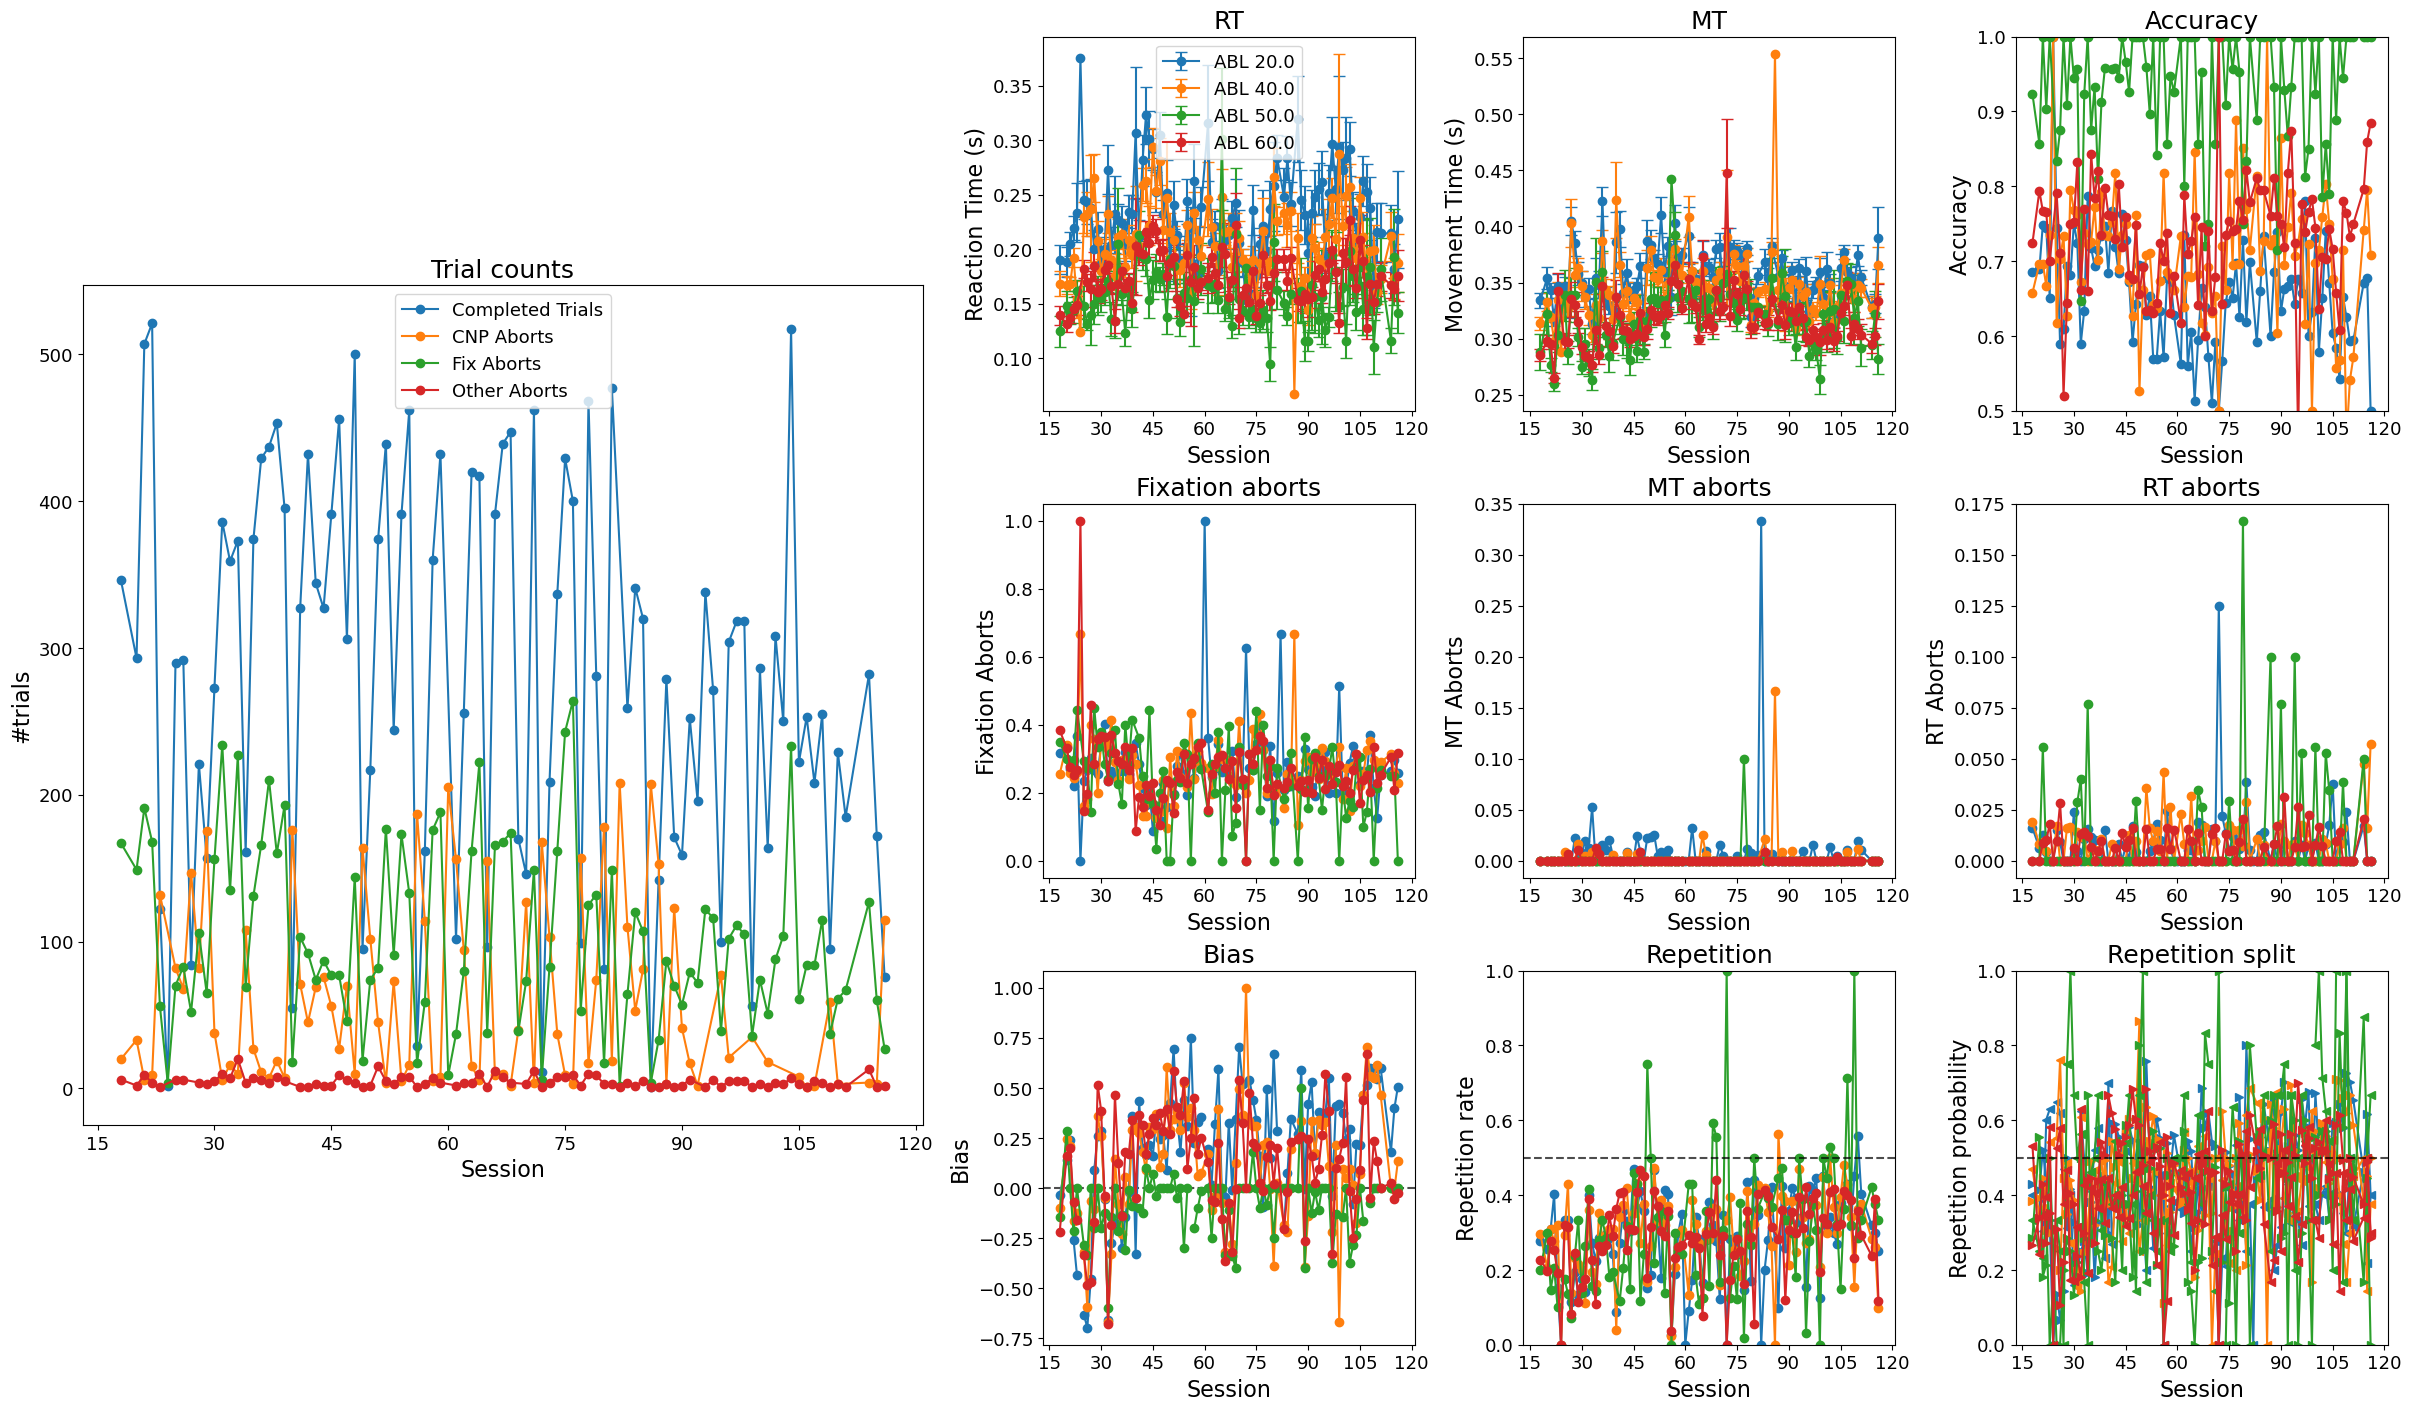

In [7]:
from Pipeline.across_sessions import plot_across_sessions_combined

fig_across = plot_across_sessions_combined(
    across_prepared,
    regions=regions,
    figsize=(24, 14),
)

## 5. Figure 2: Daily Summary + JND

Large slide-friendly figure with animal info, RT, MT, psychometric, and JND.

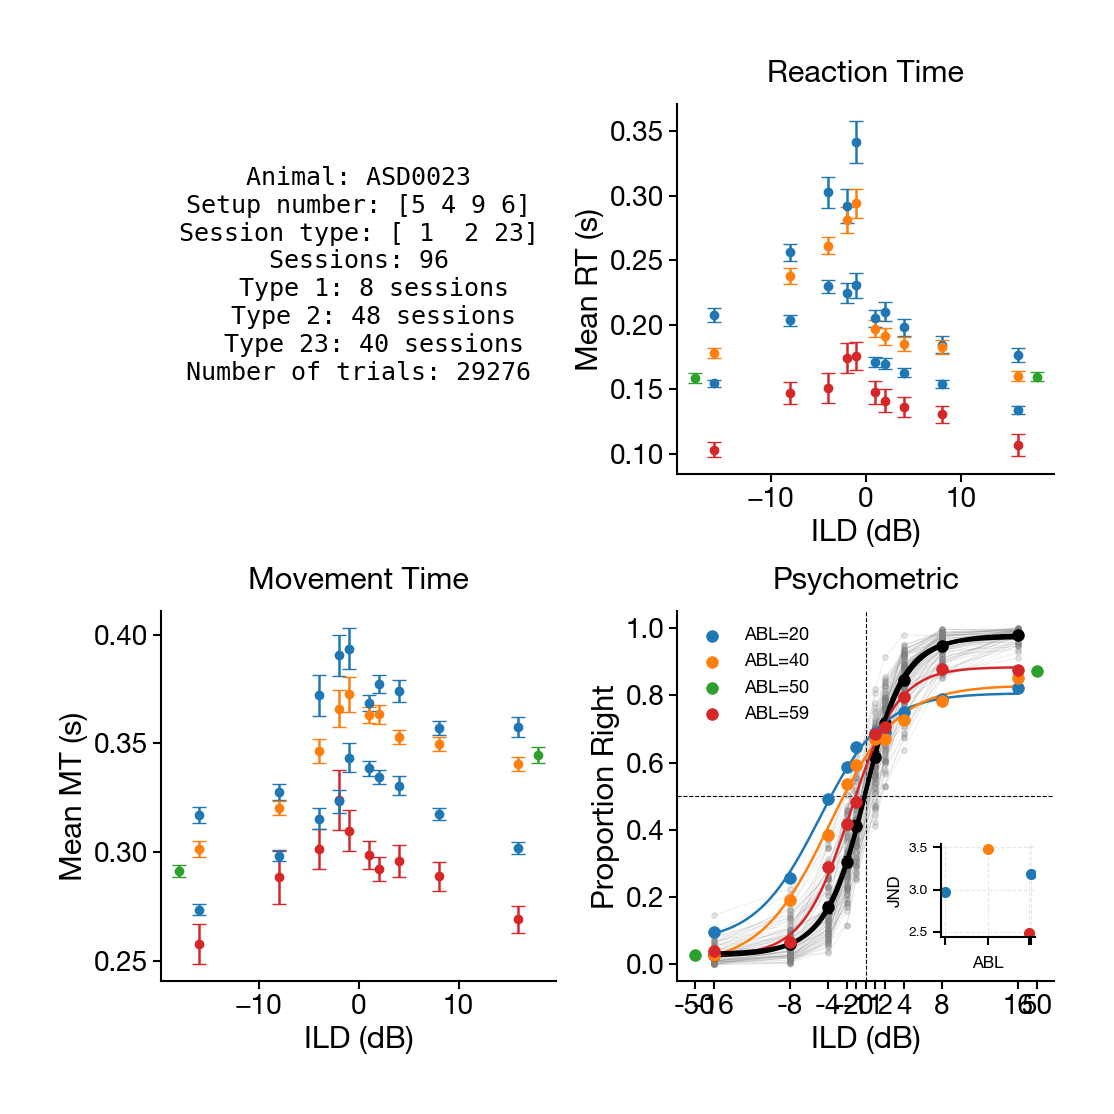

In [ ]:
import importlib
import matplotlib.pyplot as plt
import Pipeline.daily_plots as daily_plots

importlib.reload(daily_plots)
plt.close("all")

fig_daily = daily_plots.plot_daily_animal_summary_with_jnd(
    daily_prepared,
    reference=reference,
    figsize=(10, 10),
)

## 6. Figure 3: Timing Histograms

Slide-friendly timing distribution histograms for fixation, CNP, RT, MT, and LNP timings.

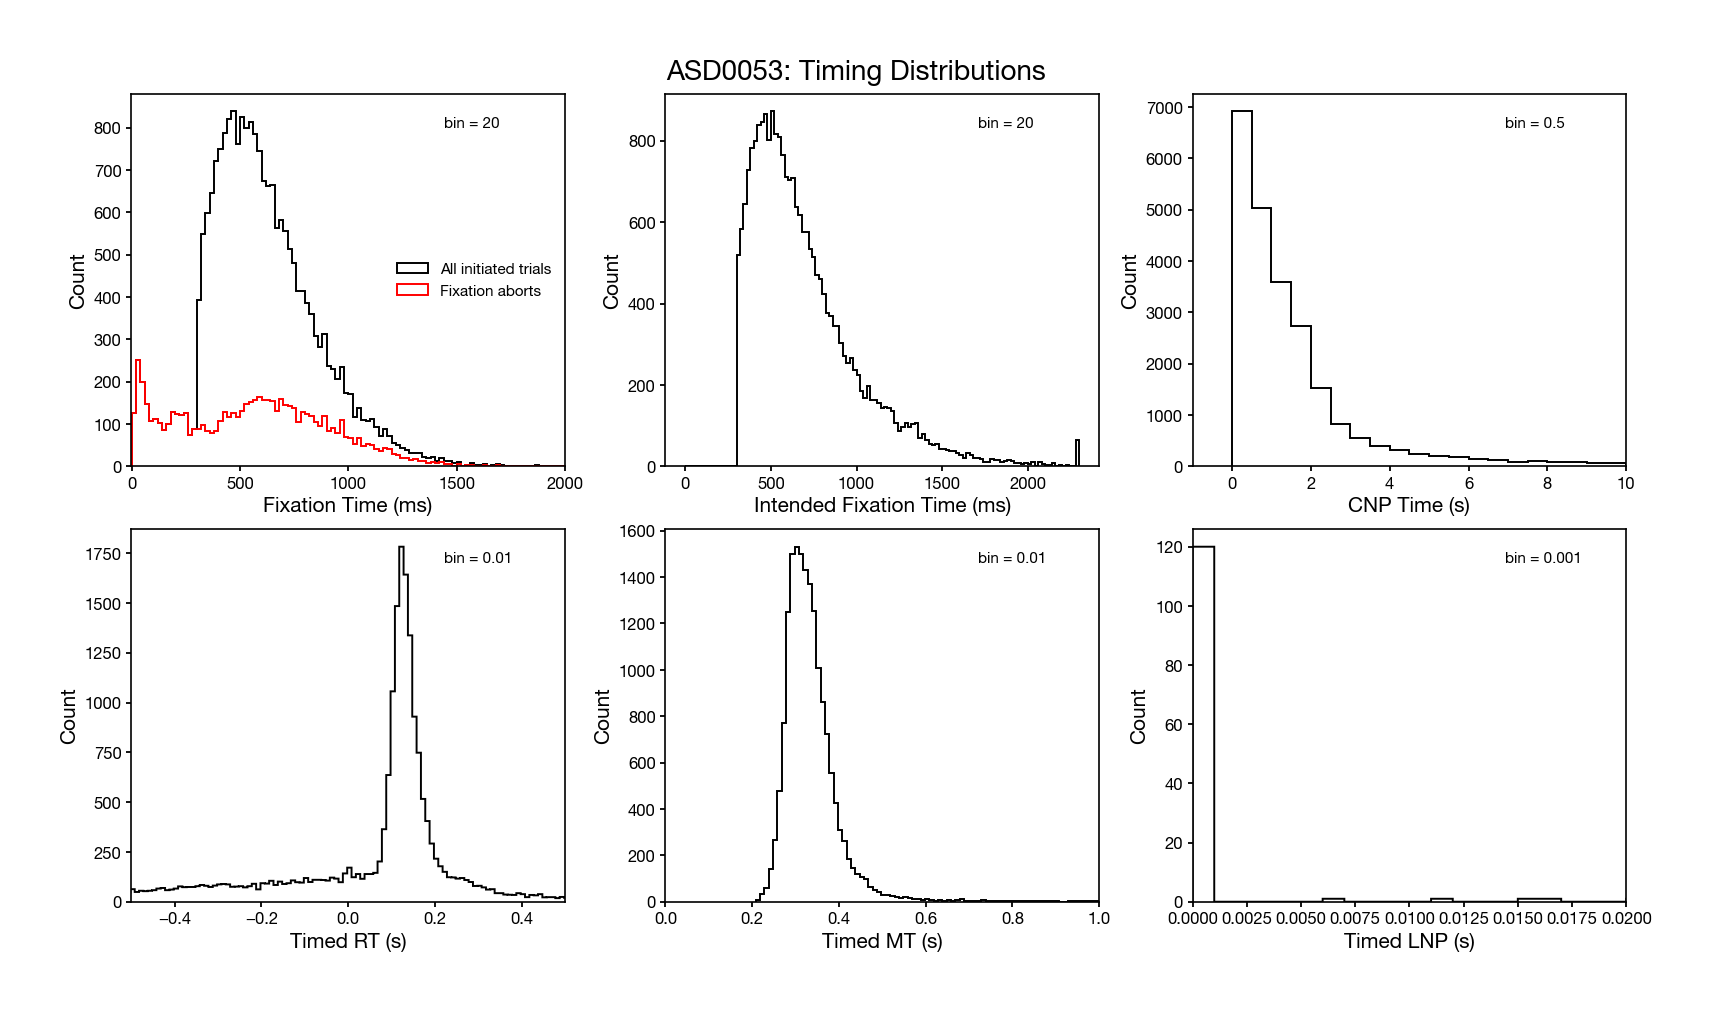

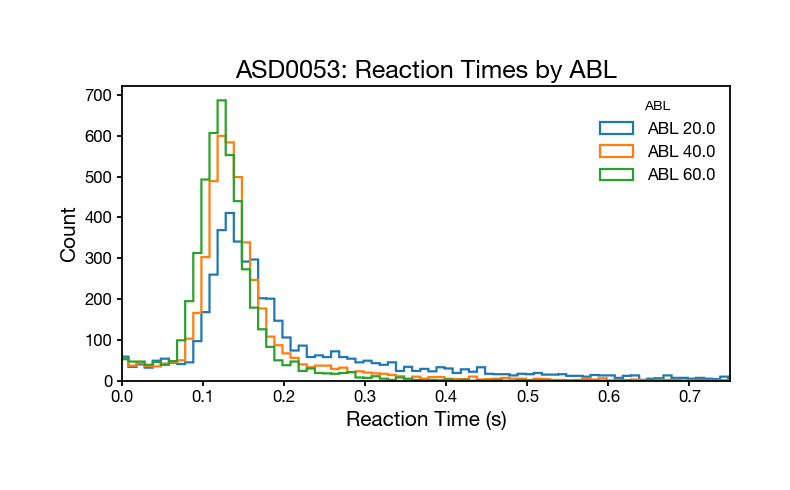

In [9]:
import importlib
import matplotlib.pyplot as plt
import Pipeline.daily_plots as daily_plots

importlib.reload(daily_plots)

fig_hist = daily_plots.plot_timing_histograms(
    daily_prepared,
    subject_id=subject_id,
    figsize=(16, 9),
)

fig_rt_by_abl = daily_plots.plot_rt_histogram_by_abl(
    daily_prepared,
    subject_id=subject_id,
    figsize=(7, 4),
)

## 7. In progress: Optional Session Exclusion Report

In progress - bias cutoff should be gathered from all sessions, not session by session

In [11]:
from Pipeline.across_sessions import filter_sessions_report

sessions_ok, report, excluded, df_clean = filter_sessions_report(
    across_prepared,
    min_trials=100,
    trials_use="total",
    history_n=10,
    min_prev=5,
    k=3.0,
    min_perf=0.7,
    require_perf_min_completed=20,
)

print("Excluded sessions:")
for line in report:
    print("-", line)

print(f"Clean rows: {len(df_clean)}")

Excluded sessions:
- Rat ASD0053, Session 6 excluded: too few total trials (43) < 100
- Rat ASD0053, Session 13 excluded: extreme bias |0.199| > cutoff 0.161
- Rat ASD0053, Session 14 excluded: extreme bias |0.165| > cutoff 0.157
- Rat ASD0053, Session 21 excluded: extreme bias |-0.205| > cutoff 0.173
- Rat ASD0053, Session 40 excluded: extreme bias |0.333| > cutoff 0.242
Clean rows: 22208


## 8. Optional Save For Google Slides

This writes high-resolution PNG files into `outputs/daily_animal_review/`.

In [ ]:
if SAVE_FIGURES:
    out_dir = Path(OUTPUT_DIR) if OUTPUT_DIR else ROOT / "outputs" / "daily_animal_review" / LINE / COHORT / subject_id
    out_dir.mkdir(parents=True, exist_ok=True)
    fig_across.savefig(out_dir / f"{subject_id}_01_across_sessions.png", dpi=FIGURE_DPI, bbox_inches="tight")
    fig_daily.savefig(out_dir / f"{subject_id}_02_daily_summary_jnd.png", dpi=FIGURE_DPI, bbox_inches="tight")
    fig_hist.savefig(out_dir / f"{subject_id}_03_timing_histograms.png", dpi=FIGURE_DPI, bbox_inches="tight")
    fig_rt_by_abl.savefig(out_dir / f"{subject_id}_04_rt_by_abl.png", dpi=FIGURE_DPI, bbox_inches="tight")
    print(out_dir)